In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import argparse

Creare uno script python che analizzi i dati prodotti da 2 canali di un oscilloscopio:
- calcolare la derivata dei segnali attraverso la diffrenza centrale;
- produrre il grafico dei segnali in uscita all'oscilloscopio e dei segnali derivati;
- ricavare la posizione e il valore dei minimi dei segnali;
- trovare le coincidenze fra i due segnali;
- stimare l'efficienza dei due canali dell'oscilloscopio.

In [2]:
osc_data=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e6/oscilloscope.csv', sep=',')
#array dai dati
CH1= np.array([osc_data['time'], osc_data['signal1']])
print(CH1[0]) #-->time
print(CH1[1]) #-->signal1
CH2= np.array([osc_data['time'], osc_data['signal2']])
print(CH2[1]) # --<signal2

[0.0000e+00 1.0000e+00 2.0000e+00 ... 4.9913e+04 4.9914e+04 4.9915e+04]
[ 0.63  2.75  1.81 ... -0.83 -1.16 -1.42]
[ 1.18 -1.78 -0.07 ...  2.01  3.63  0.63]


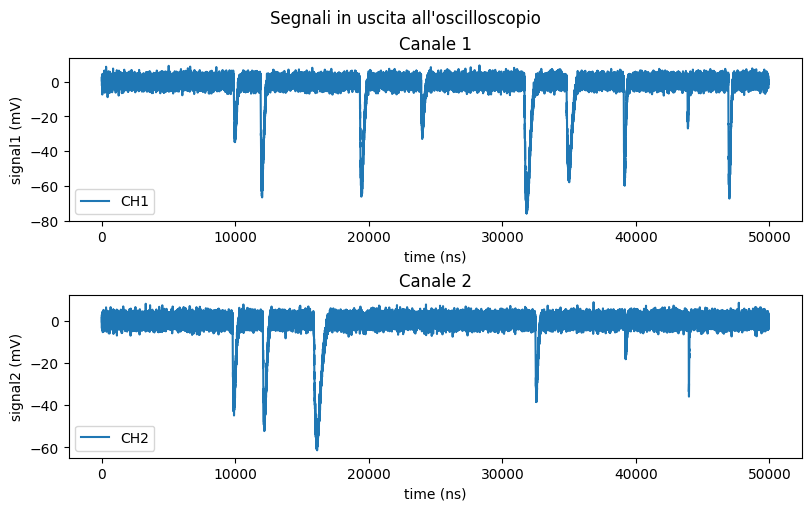

In [3]:
# Grafici dei segnali all'uscita dall'oscilloscopio:
fig, ax=plt.subplots(2,1, figsize=(8,5), layout='constrained')
fig.suptitle("Segnali in uscita all'oscilloscopio")
ax[0].set_title('Canale 1')
ax[0].plot(CH1[0],CH1[1], label='CH1')
ax[0].set_ylabel('signal1 (mV)')
ax[1].set_title('Canale 2')
ax[1].plot(CH2[0],CH2[1], label='CH2')
ax[1].set_ylabel('signal2 (mV)')

for a in ax.flat:
    a.set(xlabel='time (ns)')
    a.legend()

### Derivata dei Segnali

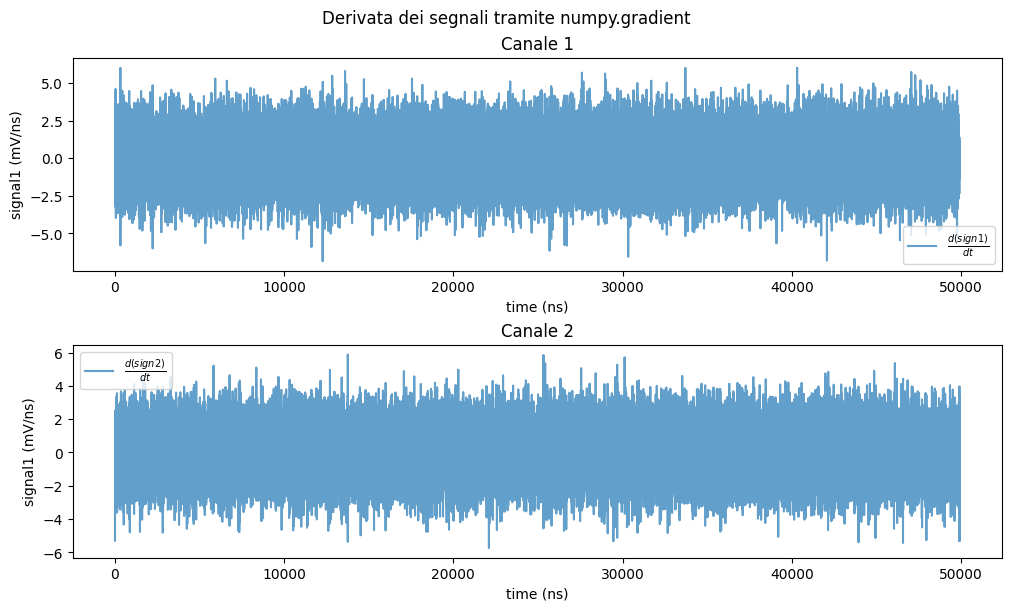

In [4]:
#Derivate dei segnali
dsign1_noise=np.gradient(CH1[1], CH1[0], edge_order=1)
dsign2_noise=np.gradient(CH2[1], CH2[0], edge_order=2)

fig, ax=plt.subplots(2,1, figsize=(10,6), layout='constrained')
fig.suptitle("Derivata dei segnali tramite numpy.gradient")
ax[0].set_title('Canale 1')
ax[0].plot(CH1[0], dsign1_noise, label=r'$\frac{d(sign1)}{dt}$', alpha=0.7)
ax[0].set_ylabel('signal1 (mV/ns)')
ax[1].set_title('Canale 2')
ax[1].plot(CH1[0], dsign2_noise, label=r'$\frac{d(sign2)}{dt}$', alpha=0.7)
ax[1].set_ylabel('signal1 (mV/ns)')

for a in ax.flat:
    a.set(xlabel='time (ns)')
    a.legend()
    #a.set_xlim(9600,10300)

Implemento la differenza centrale per cercare di diminuire il rumore.

In [5]:
#general central_diff function
# nh must be EVEN
def central_diffg(xx, yy, nh):
    dd = yy[nh:] - yy[:-nh]
    hh = xx[nh:] - xx[:-nh]
    for ih in range(int(nh/2)):
        dd = np.append(yy[nh-ih-1]-yy[0], dd)
        dd = np.append(dd, yy[-1]-yy[-(nh-ih)])
    
        hh = np.append(xx[nh-ih-1]-xx[0], hh)
        hh = np.append(hh, xx[-1]-xx[-(nh-ih)])
    
    return dd/hh

In [11]:
# Calcolo derivate con differenza centrale
dc2_ch1=central_diffg(CH1[0], CH1[1], 2)
dc2_ch2=central_diffg(CH2[0], CH2[1], 2)

dc100_ch1=central_diffg(CH1[0], CH1[1], 100)
dc100_ch2=central_diffg(CH2[0], CH2[1], 100)

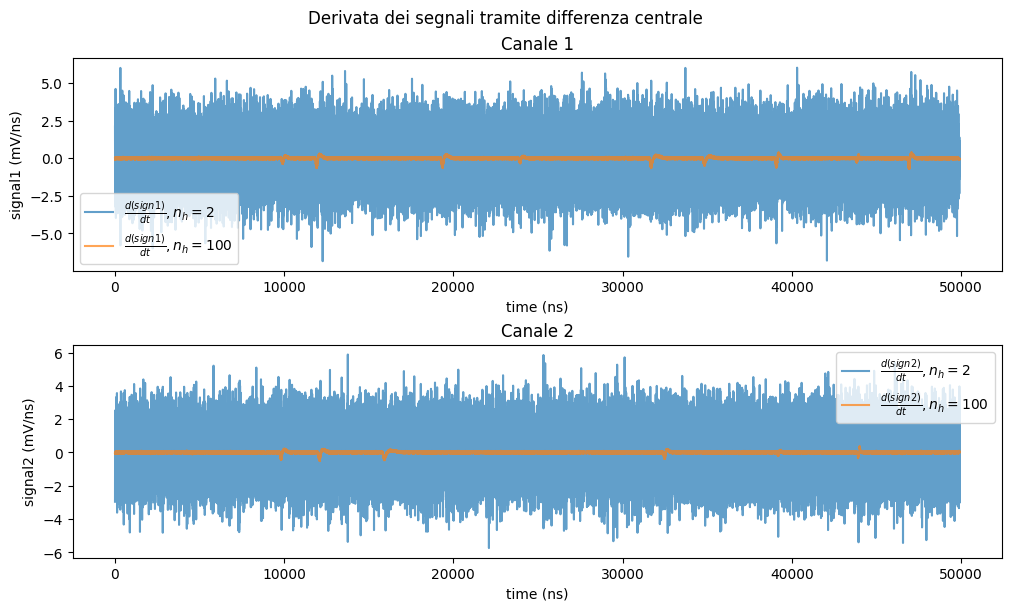

In [12]:
fig, ax=plt.subplots(2,1, figsize=(10,6), layout='constrained')
fig.suptitle("Derivata dei segnali tramite differenza centrale")
ax[0].set_title('Canale 1')
ax[0].plot(CH1[0], dc2_ch1, label=r'$\frac{d(sign1)}{dt}, n_h=2$', alpha=0.7)
ax[0].plot(CH1[0], dc100_ch1, label=r'$\frac{d(sign1)}{dt}, n_h=100$', alpha=0.7)
ax[0].set_ylabel('signal1 (mV/ns)')
ax[1].set_title('Canale 2')
ax[1].plot(CH1[0], dc2_ch2, label=r'$\frac{d(sign2)}{dt}, n_h=2$', alpha=0.7)
ax[1].plot(CH1[0], dc100_ch2, label=r'$\frac{d(sign2)}{dt}, n_h=100$', alpha=0.7)
ax[1].set_ylabel('signal2 (mV/ns)')

for a in ax.flat:
    a.set(xlabel='time (ns)')
    a.legend()
    #a.set_xlim(9600,10300)

** se nh è troppo grande non permette di trovare i minimi del segnale

La convoluzione è un'operazione matematica che combina due funzioni o sequenze per produrre una terza funzione che esprime come la forma di una viene modificata dal altra.

In termini pratici, la **convoluzione** è utilizzata per calcolare la risposta di un sistema a un impulso; può essere vista come una media pesata del segnale di ingresso, dove la funzione peso è la risposta del sistema traslata nel tempo.
Nel caso in esame, viene utilizzata per enfatizzare le frequenze più grandi in valore assoluto.

Text(0, 0.5, 'V/s (mV/ns)')

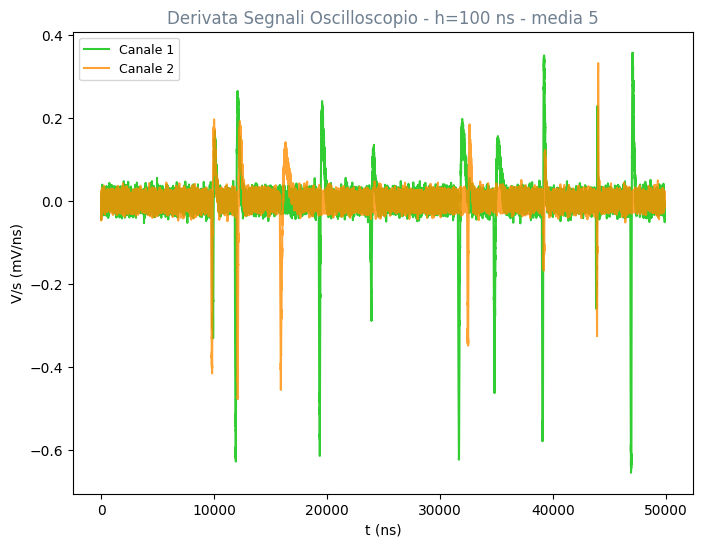

In [8]:
der_sig1 = np.convolve(dc100_ch1,  np.ones(5), 'same') / 5
der_sig2 = np.convolve(dc100_ch2,  np.ones(5), 'same') / 5


# grafico derivata dh=100 avg 5
plt.subplots(figsize=(8, 6))
plt.title('Derivata Segnali Oscilloscopio - h=100 ns - media 5', fontsize=12, color='slategray')
plt.plot(CH1[0], der_sig1, color='limegreen',   label='Canale 1')
plt.plot(CH2[0], der_sig2, color='darkorange',  label='Canale 2', alpha=0.8)                 
plt.legend(fontsize=9)
plt.xlabel('t (ns)')
plt.ylabel('V/s (mV/ns)')

### Ricerca dei Minimi dei due segnali

Si selezionano i punti con derivata vicina a zero (<0.015 mV) e segnale superiore alla soglia di 10 mV (in negativo).
Se più valori soddisfano la condizione nella posizione intorno al minimo, viene considerato solo il primo valore in una finestra di 20 ns.

In [13]:
selmask_sig1= (np.abs(der_sig1) < 0.015) & (CH1[1]<-10)
selmask_sig2= (np.abs(der_sig2) < 0.015) & (CH2[1]<-10)

print('---der0 sig1 ---', CH1[0][selmask_sig1])
print('---der0 sig2 ---', CH2[0][selmask_sig2])


---der0 sig1 --- [ 9973.  9974.  9975.  9976.  9977.  9978.  9981.  9982.  9984. 11996.
 11997. 12001. 12002. 12003. 12004. 19452. 19453. 19455. 19456. 19457.
 19458. 19459. 19460. 24015. 24016. 31822. 31823. 31824. 31825. 31826.
 31827. 31828. 31829. 31830. 31831. 31832. 31834. 31835. 31836. 31837.
 31838. 31839. 31840. 34970. 34971. 34972. 34973. 34974. 34975. 34976.
 34977. 34978. 34979. 34984. 34985. 34986. 34987. 34988. 39161. 39162.
 43911. 43912. 43913. 43914. 43915. 47000. 47001. 47002.]
---der0 sig2 --- [ 9896.  9898.  9908.  9909.  9910. 12173. 12174. 12175. 12176. 12177.
 12181. 12182. 12183. 12184. 12185. 12186. 12187. 12188. 16097. 16098.
 16099. 16100. 16101. 16102. 16103. 16104. 16105. 16106. 16107. 16109.
 16110. 16111. 16112. 16113. 16114. 16116. 16117. 16120. 16121. 16131.
 16132. 16133. 16134. 16135. 16136. 32552. 32554. 32555. 39261. 39262.
 39263. 39264. 39265. 39266. 43978. 43979. 43980. 43981. 43983. 43984.
 43985. 43989. 43990. 43991. 43992. 43993. 43994. 43995.

In [14]:
# accorpamento punti per Canale 1
tpeak_sig1 = np.empty(0)
vpeak_sig1 = np.empty(0)
tsum = int(CH1[0][selmask_sig1][0])
nsum = 1

for it in range(1, len(CH1[0][selmask_sig1])):
    if((CH1[0][selmask_sig1][it] - CH1[0][selmask_sig1][it-1] >20) or (it == len(CH1[0][selmask_sig1])-1)):
        #print(tsum)
        tpeak_sig1=np.append(tpeak_sig1, tsum)
        vpeak_sig1=np.append(vpeak_sig1, CH1[1][tsum] )
        tsum=int(CH1[0][selmask_sig1][it])

# accorpamento punti per Canale 2
tpeak_sig2 = np.empty(0)
vpeak_sig2 = np.empty(0)
tsum = int(CH2[0][selmask_sig2][0])
nsum = 1

for it in range(1, len(CH2[0][selmask_sig1])):
    if((CH2[0][selmask_sig2][it] - CH2[0][selmask_sig2][it-1] >20) or (it == len(CH2[0][selmask_sig1])-1)):
        #print(tsum)
        tpeak_sig2=np.append(tpeak_sig2, tsum)
        vpeak_sig2=np.append(vpeak_sig2,CH2[1][tsum])
        tsum=int(CH2[0][selmask_sig2][it])

#print(tpeak_sig1)
#print(vpeak_sig1)

(-90.0, 10.0)

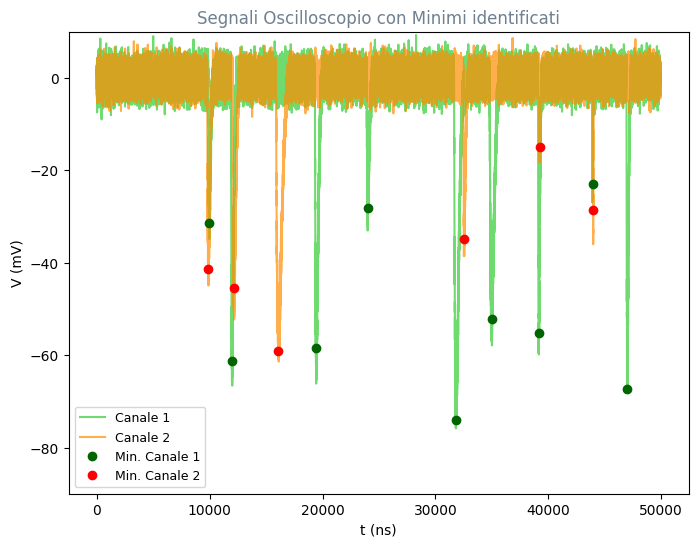

In [16]:
# Grafico Minimi dei Segnali
plt.subplots(figsize=(8,6))
plt.title('Segnali Oscilloscopio con Minimi identificati', fontsize=12, color='slategray')
plt.plot( CH1[0], CH1[1], color='limegreen',  label='Canale 1', alpha=0.7 )
plt.plot( CH2[0], CH2[1], color='darkorange', label='Canale 2', alpha=0.7 )
plt.plot( tpeak_sig1, vpeak_sig1, 'o', color='darkgreen',  label='Min. Canale 1' )
plt.plot( tpeak_sig2, vpeak_sig2, 'o', color='red',        label='Min. Canale 2' )
plt.legend(fontsize=9)
plt.xlabel('t (ns)')
plt.ylabel('V (mV)')
plt.ylim(-90, 10)

### Coincidenze dei Segnali e Stima dell'Efficienza dei canali dell'oscilloscopio

Si cercano i punti di minimo per i canali 1 e 2 che cadono nella stessa finestra temporale (200 ns)

In [19]:
tcoin1 = np.empty(0)
tcoin2 = np.empty(0)
vcoin1 = np.empty(0)
vcoin2 = np.empty(0)

window = 200
for t1, v1 in zip(tpeak_sig1, vpeak_sig1):

    for t2, v2 in zip(tpeak_sig2, vpeak_sig2):
        if np.abs(t2-t1) < window:
            tcoin1 = np.append(tcoin1, t1)
            tcoin2 = np.append(tcoin2, t2)
            vcoin1 = np.append(vcoin1, v1)
            vcoin2 = np.append(vcoin2, v2)
        if t2 > t1 :
            break

Efficienza Canali:

In [21]:
print('--------------------------------------------')
print(' Numero Coincidenze        :', len(tcoin1) )
print(' Tempo Coincidenze Canale 1:', tcoin1)
print(' Tempo Coincidenze Canale 2:', tcoin2)
print(' Coincidenze t2-t1         :', tcoin2-tcoin1)
print(' Efficenza Canale 1        : {:.2f}'.format( len(tcoin1)/len(tpeak_sig1)) )
print(' Efficenza Canale 2        : {:.2f}'.format( len(tcoin2)/len(tpeak_sig2)) )

--------------------------------------------
 Numero Coincidenze        : 4
 Tempo Coincidenze Canale 1: [ 9973. 11996. 39161. 43911.]
 Tempo Coincidenze Canale 2: [ 9896. 12173. 39261. 43978.]
 Coincidenze t2-t1         : [-77. 177. 100.  67.]
 Efficenza Canale 1        : 0.44
 Efficenza Canale 2        : 0.67


### Gestione dello script da riga di comando

In [ ]:
def parse_arguments():
    parser=argparse.ArgumentParser( description='Analisi Segnali Oscillosopio a 2 Canali',
                                   usage= 'python3 e6_e3.py  --opzione')
    parser.add_argument('-dset', '--dataset', action='store', default='oscilloscope.csv', help='segnali raccolti dai 2 canali dell oscilloscopio')
    parser.add_argument('-ch', '--channels', action='store_true', help='Grafici dei segnali in uscita dai 2 canali')
    parser.add_argument('-dc', '--der_sig', action='store_true', help='Derivate dei Segnali')
    parser.add_argument('-min', '--min_sig', action='store_true', help='Minimi dei Seganli')
    parser.add_argument('-cmp', 'compare_channels', action='store_true', help='Confronto tra i due canali')

    return parser.parse_args()

In [ ]:
def oscilloscope_analysis():

    args=parse_arguments()

    if args.channels == True:
        signals_plot()
    if args.der_cahnnels == True:
        der_sig_plot()
    if args.der_sig == True:
        min_seek()
        min_sig_plot()
    if args.compare_channels == True:
       (tc1, vc1), (tc2, vc2)=same_ch()
       
       print('--------------------------------------------')
       print(' Numero Coincidenze        :', len(tc1) )
       print(' Tempo Coincidenze Canale 1:', tc1)
       print(' Tempo Coincidenze Canale 2:', tc2)
       print(' Coincidenze t2-t1         :', tc2-tc1)
       print(' Efficenza Canale 1        : {:.2f}'.format( len(tc1)/len(tpeak_sig2)) )
       print(' Efficenza Canale 2        : {:.2f}'.format( len(tc2)/len(tpeak_sig1)) )
    
if __name__=="__main__":
   oscilloscope_analysis()
        